In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import time
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [15]:
(x_data, y_data), (x_test,y_test) = (
    keras.datasets.fashion_mnist.load_data()
)

In [16]:
x_data.shape, y_data.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [17]:
class_names = [
    "футболка",
    "брюки",
    "пуловер",
    "платье",
    "пальто",
    "сандали",
    "рубашка",
    "кроссовки",
    "сумка",
    "батильоны",
]

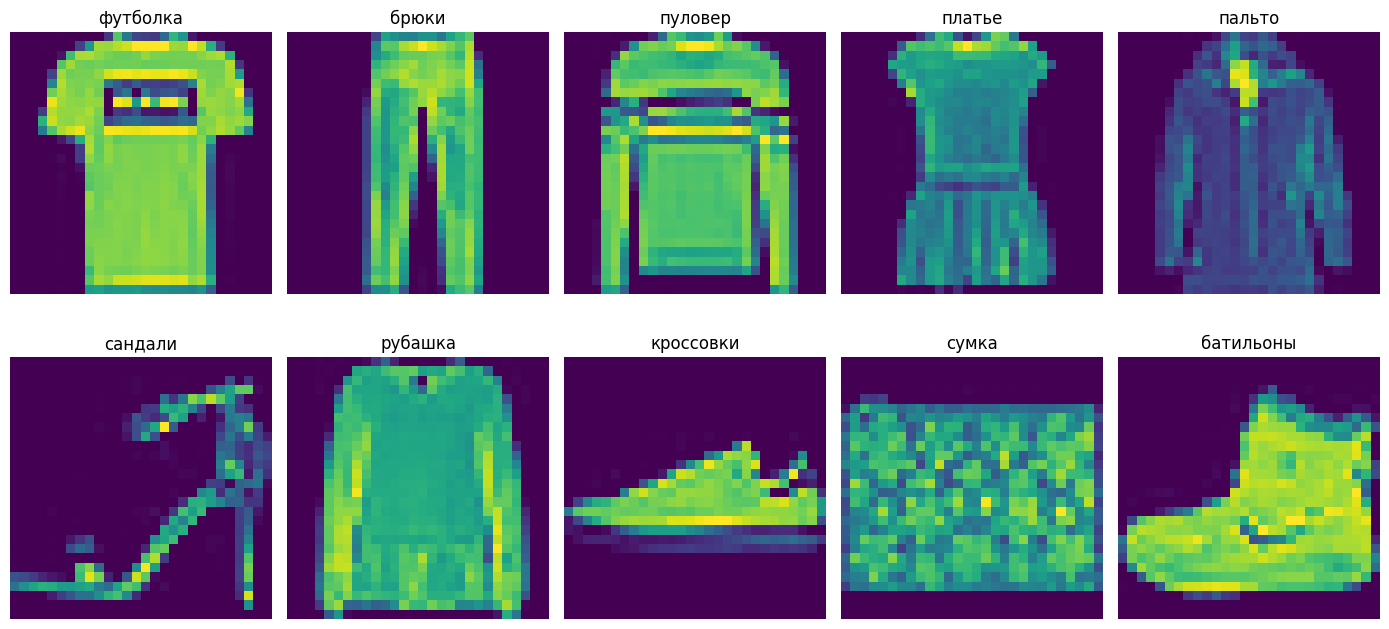

In [18]:
fig, axes = plt.subplots(2,5,figsize=(14,7))

for class_id, ax in enumerate(axes.flat):
    index = np.flatnonzero(y_data == class_id)[0]
    ax.imshow(x_data[index])
    ax.set_title(class_names[class_id])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
x_val, y_val = x_data[:10000],y_data[:10000]
x_train,y_train = x_data[10000:],y_data[10000:]

In [20]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_val.shape, y_val.shape

((50000, 28, 28),
 (50000,),
 (10000, 28, 28),
 (10000,),
 (10000, 28, 28),
 (10000,))

In [21]:
batch_size = 64
image_size = (32,32)

def prepare_image(images,labels):
    images = tf.cast(images,tf.float32)
    images = images[:, :, :, tf.newaxis] # новый канал (монохромный - 1)
    images = tf.image.resize(images,image_size)
    images = tf.image.grayscale_to_rgb(images)
    return images, labels

def make_dataset(images, labels):
    dataset = tf.data.Dataset.from_tensor_slices((images,labels))
    dataset = dataset.shuffle(buffer_size = 10000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(
        prepare_image,
        num_parallel_calls = tf.data.AUTOTUNE # автоматическая подгрузка изображений в буфер для ускорения работы 
    )
    return dataset.prefetch(tf.data.AUTOTUNE)

In [22]:
train_dataset = make_dataset(x_train,y_train)
validation_dataset = make_dataset(x_val, y_val)
test_dataset = make_dataset(x_test,y_test)

I0000 00:00:1791451781.984594      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791451781.987932      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
data_augmentations = keras.Sequential([
    keras.layers.RandomFlip("horisontal"),
    keras.layers.RandomRotation(0.5)
])

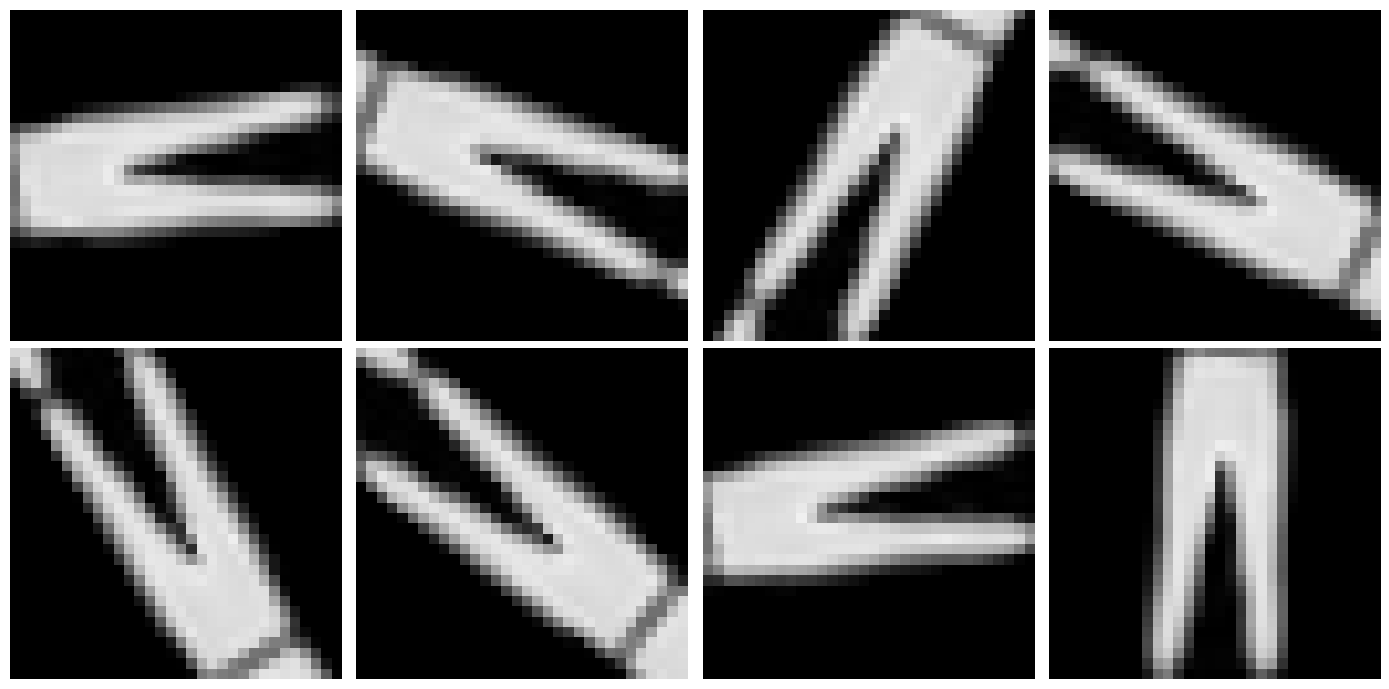

In [24]:
images,labels = next(iter(train_dataset))
fig, axes = plt.subplots(2,4,figsize=(14,7))

for ax in axes.flat:
    augmented = data_augmentations(images[:1])
    ax.imshow(np.clip(augmented[0].numpy()/ 255, 0,1))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [25]:
base_model = keras.applications.MobileNetV2(
    input_shape = image_size + (3,),
    include_top = False,
    weights = "imagenet"
)
base_model.trainable = False

/tmp/ipykernel_58/1717757467.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
inputs = keras.Input(shape = image_size + (3,))

x = data_augmentations(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training = False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)

outputs = keras.layers.Dense(10,activation = "softmax")(x)
model = keras.Model(inputs, outputs)


In [27]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.0001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
initial_epochs = 10

start = time.perf_counter()
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = initial_epochs
)
frozen_time = time.perf_counter() - start


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.1296 - loss: 2.2944 - val_accuracy: 0.2109 - val_loss: 2.2390
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1629 - loss: 2.2702 - val_accuracy: 0.2670 - val_loss: 2.1943
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1775 - loss: 2.2532 - val_accuracy: 0.2808 - val_loss: 2.1626
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1868 - loss: 2.2377 - val_accuracy: 0.2860 - val_loss: 2.1366
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1925 - loss: 2.2249 - val_accuracy: 0.2881 - val_loss: 2.1165
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1913 - loss: 2.2185 - val_accuracy: 0.2886 - val_loss: 2.1013
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1950 - loss: 2.2078 - val_accuracy: 0.2921 - val_loss: 2.0851
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1947 - loss: 2.2035 - val_acc

In [29]:
frozen_loss,frozen_accuracy = model.evaluate(test_dataset,verbose = 0)
frozen_loss,frozen_accuracy

(2.0462188720703125, 0.2996000051498413)

In [30]:
base_model.trainable = True

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.0001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [31]:
initial_epochs = 15

start = time.perf_counter()
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = initial_epochs
)
frozen_time = time.perf_counter() - start


Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.4637 - loss: 1.6965 - val_accuracy: 0.2610 - val_loss: 1.9230
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.6521 - loss: 1.0151 - val_accuracy: 0.4308 - val_loss: 1.6008
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.7110 - loss: 0.8302 - val_accuracy: 0.5590 - val_loss: 1.2343
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.7433 - loss: 0.7353 - val_accuracy: 0.5954 - val_loss: 1.1727
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.7663 - loss: 0.6662 - val_accuracy: 0.7276 - val_loss: 0.7831
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.7818 - loss: 0.6150 - val_accuracy: 0.7680 - val_loss: 0.6707
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.7957 - loss: 0.5736 - val_accuracy: 0.7666 - val_loss: 0.6846
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.8088 - loss: 0.5357 - 

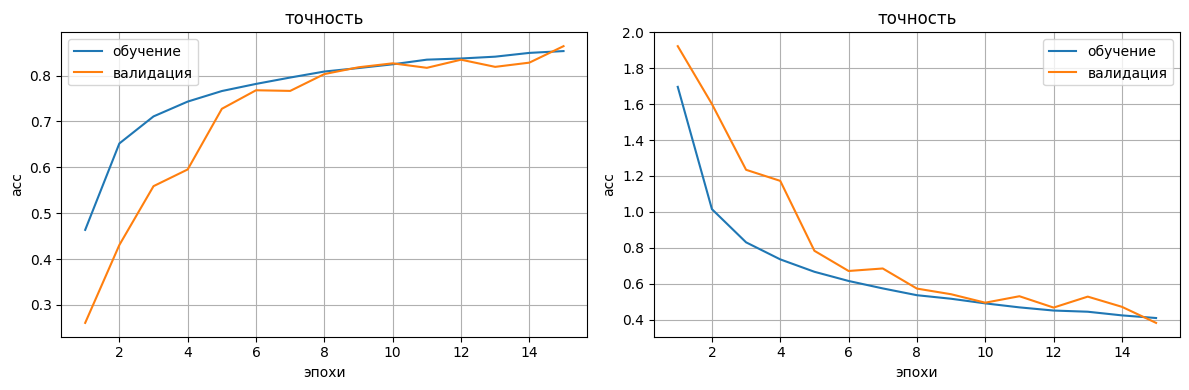

In [39]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs,history.history["accuracy"],label = "обучение")
plt.plot(epochs,history.history["val_accuracy"],label = "валидация")
plt.title("точность")
plt.xlabel("эпохи")
plt.ylabel("acc")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,history.history["loss"],label = "обучение")
plt.plot(epochs,history.history["val_loss"],label = "валидация")
plt.title("точность")
plt.xlabel("эпохи")
plt.ylabel("acc")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

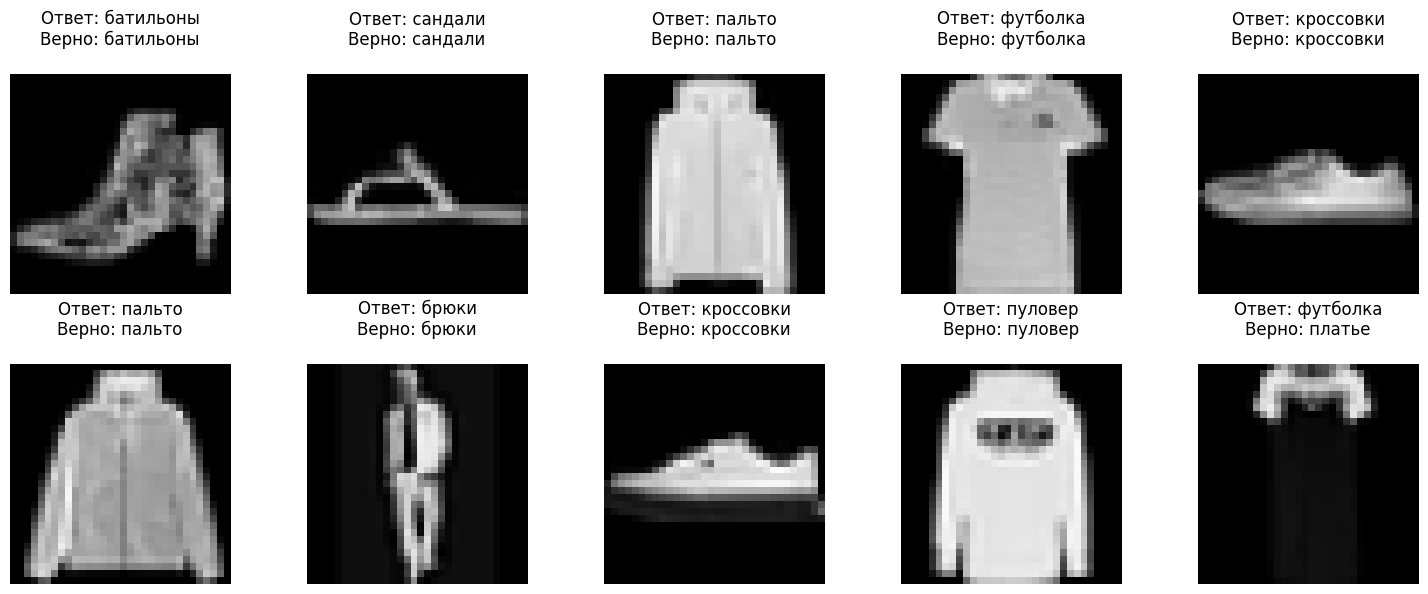

In [51]:
images, labels = next(iter(test_dataset))

prob = model.predict(images, verbose=0)
pred = prob.argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i >= len(images):
        ax.axis("off")
        continue

    ax.imshow(np.clip(images[i].numpy() / 255.0, 0, 1))

    pred_class = int(pred[i])
    true_class = int(labels[i].numpy())

    ax.set_title(
        f"Ответ: {class_names[pred_class]}\n"
        f"Верно: {class_names[true_class]}\n"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# *****задание 2*****

In [3]:
(mnist_data, mnist_labels), (mnist_test, _) = (
    keras.datasets.mnist.load_data()
)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
mnist_train, mnist_val = train_test_split(
    mnist_data,
    test_size=10000,
    random_state=67,
    stratify=mnist_labels
)

In [7]:
mnist_train = (
    mnist_train.astype("float32")[..., None] / 255
)

In [8]:
mnist_val = (
    mnist_val.astype("float32")[..., None] / 255
)

In [9]:
mnist_test = (
    mnist_test.astype("float32")[..., None] / 255
)

In [10]:
print(
    mnist_train.shape,
    mnist_val.shape,
    mnist_test.shape
)

(50000, 28, 28, 1) (10000, 28, 28, 1) (10000, 28, 28, 1)


In [12]:
rng = np.random.default_rng(67)

def add_noize(images):
    noize = rng.normal(loc = 0,scale = 0.5,size = images.shape)
    return np.clip(images+noize,0,1)

In [27]:
train_noizy = add_noize(mnist_train)
test_noizy= add_noize(mnist_test)
val_noizy = add_noize(mnist_val)


In [29]:
encoder2 = keras.Sequential([
    keras.Input(shape = (28,28,1)),

    keras.layers.Conv2D(
        filters=32,kernel_size=3,strides=2,padding="same",activation="relu" #первая свертка на 32 канала
    ),
    keras.layers.Conv2D(
        filters=64,kernel_size=3,strides=2,padding="same",activation="relu" #вторая свертка на 64 канала
    ),
    keras.layers.Flatten(), #один длинный вектор
    keras.layers.Dense(16) #обучается сжимать до 16 чисел
    
],name = "encoder2")

decoder2 = keras.Sequential([
    keras.Input(shape = (16,)),

    keras.layers.Dense(7*7*64),
    keras.layers.Reshape((7,7,64)),

    # (7,7,64) -> (14,14,64) -> (28,28,64) -> (28,28,1)
    keras.layers.Conv2DTranspose(
        filters=64,kernel_size=3,strides=2,padding="same",activation="relu" 
    ),
    keras.layers.Conv2DTranspose(
        filters=32,kernel_size=3,strides=2,padding="same",activation="relu" 
    ),
    keras.layers.Conv2DTranspose(
        filters=1,kernel_size=3,padding="same",activation="sigmoid" #получаем изображение 
    )
    
],name = "decoder2")


ae2 = keras.Sequential([encoder2,decoder2],name = "ae2")

ae2.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
),

(None,)

In [36]:
encoder3 = keras.Sequential([
    keras.Input(shape = (28,28,1)),

    keras.layers.Conv2D(
        filters=32,kernel_size=3,strides=2,padding="same",activation="relu" #первая свертка на 32 канала
    ),
    keras.layers.Conv2D(
        filters=64,kernel_size=3,strides=2,padding="same",activation="relu" #вторая свертка на 64 канала
    ),
    keras.layers.Conv2D(
        filters=128,kernel_size=3,strides=1,padding="same",activation="relu" #третья свертка на 128 канала
    ),
    keras.layers.Flatten(), #один длинный вектор
    keras.layers.Dense(16) #обучается сжимать до 16 чисел
    
],name = "encoder3")

decoder3 = keras.Sequential([
    keras.Input(shape = (16,)),

    keras.layers.Dense(7*7*128),
    keras.layers.Reshape((7,7,128)),

    keras.layers.Conv2DTranspose(
        filters=128,kernel_size=3,strides=1,padding="same",activation="relu" 
    ),
    keras.layers.Conv2DTranspose(
        filters=64,kernel_size=3,strides=2,padding="same",activation="relu" 
    ),
    keras.layers.Conv2DTranspose(
        filters=32,kernel_size=3,strides=2,padding="same",activation="relu" 
    ),
    keras.layers.Conv2DTranspose(
        filters=1,kernel_size=3,strides=1,padding="same",activation="sigmoid" #получаем изображение 
    )
    
],name = "decoder3")


ae3 = keras.Sequential([encoder3,decoder3],name = "ae3")

ae3.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss = "mse"
),

(None,)

In [31]:
ae2.summary()

Model: "ae2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder2 (Sequential)           │ (None, 16)             │        69,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder2 (Sequential)           │ (None, 28, 28, 1)      │       108,993 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,001 (695.32 KB)

 Trainable params: 178,001 (695.32 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
ae3.summary()

Model: "ae3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder3 (Sequential)           │ (None, 16)             │       193,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder3 (Sequential)           │ (None, 56, 56, 1)      │       346,753 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,793 (2.06 MB)

 Trainable params: 539,793 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
start = time.perf_counter()

history_ae2 = ae2.fit(
    x = train_noizy,
    y = mnist_train,
    validation_data = (val_noizy,mnist_val),
    epochs=30,
    batch_size=128
)
time_ae2 = time.perf_counter() - start

Epoch 1/30
 28/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2067

I0000 00:00:1791542719.670689    1175 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0644 - val_loss: 0.0300
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0231 - val_loss: 0.0198
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0186 - val_loss: 0.0179
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0171 - val_loss: 0.0167
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0162 - val_loss: 0.0160
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0156 - val_loss: 0.0157
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0151 - val_loss: 0.0155
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0148 - val_loss: 0.0153
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0145 - val_loss: 0.0151
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0143 - val_loss: 0.0149
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0141 - val_loss: 0.0148
Epoch 12/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 

In [34]:
time_ae2

87.48054623600001

In [37]:
start = time.perf_counter()

history_ae3 = ae3.fit(
    x = train_noizy,
    y = mnist_train,
    validation_data = (val_noizy,mnist_val),
    epochs=30,
    batch_size=128
)
time_ae3 = time.perf_counter() - start

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0523 - val_loss: 0.0230
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0189 - val_loss: 0.0168
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0160 - val_loss: 0.0155
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0148 - val_loss: 0.0149
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0140 - val_loss: 0.0142
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0135 - val_loss: 0.0141
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0131 - val_loss: 0.0138
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0128 - val_loss: 0.0135
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0125 - val_loss: 0.0134
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0123 - val_loss: 0.0133
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0120 - val_loss: 0.0132
Epoch 12/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/st

In [38]:
time_ae3

117.34393715099986

In [48]:
mse2 = ae2.evaluate(test_noizy,mnist_test,verbose=0)
mse3 = ae3.evaluate(test_noizy,mnist_test,verbose=0)
mse_noizy = np.mean((test_noizy-mnist_test)**2)

mse_noizy,mse2,mse3

(np.float64(0.11565461769904556), 0.014048765413463116, 0.013419682160019875)

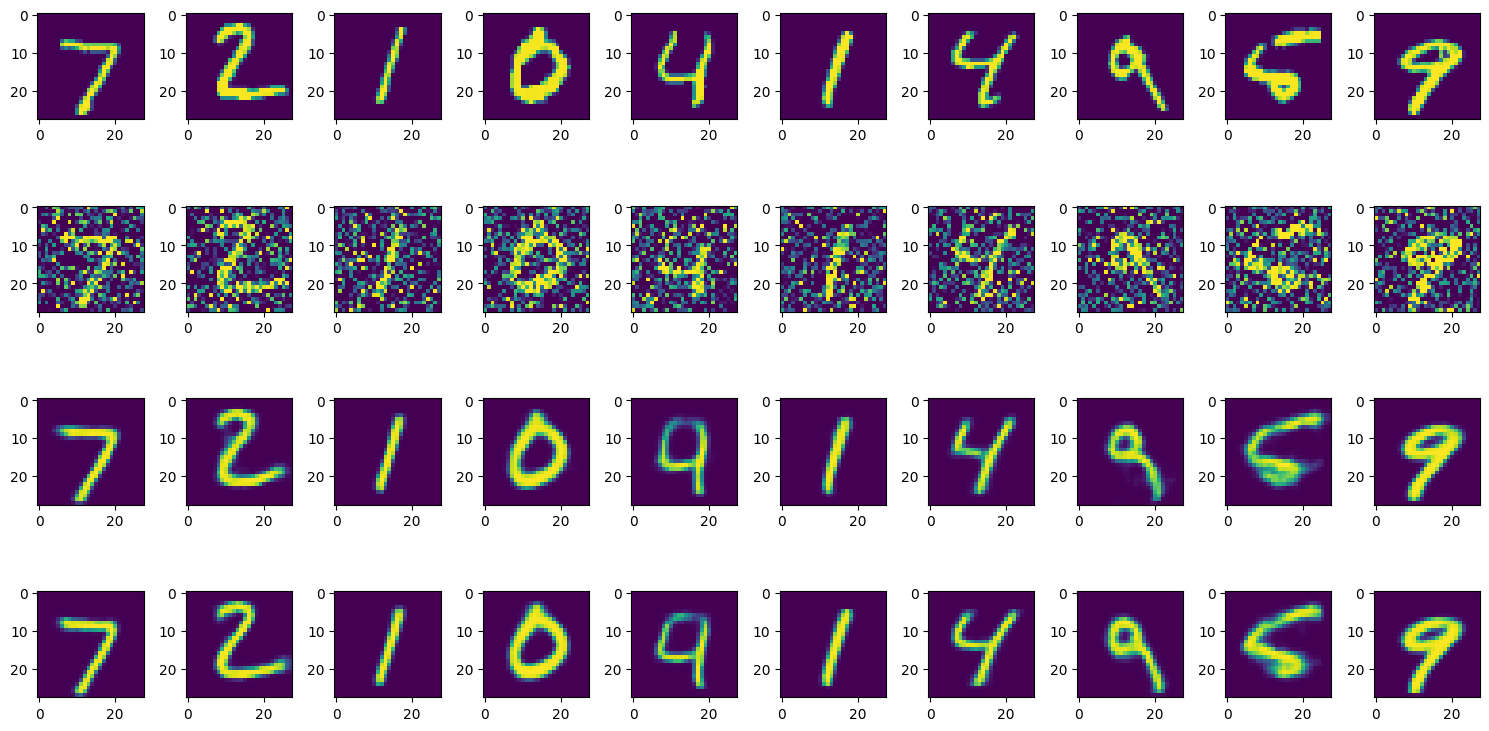

In [49]:
restored2 = ae2.predict(test_noizy[:10],verbose=0)
restored3 = ae3.predict(test_noizy[:10],verbose=0)

images = [
    mnist_test[:10],
    test_noizy[:10],
    restored2,
    restored3
]
titles = ["orig","orig+noize","2 layers","3 layers"]

fig, axes = plt.subplots(4,10,figsize = (15,8))

for row in range(4):
    for col in range(10):
        ax = axes[row,col]
        ax.imshow(images[row][col,:,:,0])

plt.tight_layout()
plt.show()